Data Cleaning Project

Name: Venecia Dsouza
Project Type: Data Analytics Internship
Task: Data Cleaning using Airbnb Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("AB_NYC_2019.csv.zip")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.shape

(48895, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 48895 entries, 0 to 48894
,Data columns (total 16 columns):
, #   Column                          Non-Null Count  Dtype  
,---  ------                          --------------  -----  
, 0   id                              48895 non-null  int64  
, 1   name                            48879 non-null  object 
, 2   host_id                         48895 non-null  int64  
, 3   host_name                       48874 non-null  object 
, 4   neighbourhood_group             48895 non-null  object 
, 5   neighbourhood                   48895 non-null  object 
, 6   latitude                        48895 non-null  float64
, 7   longitude                       48895 non-null  float64
, 8   room_type                       48895 non-null  object 
, 9   price                           48895 non-null  int64  
, 10  minimum_nights                  48895 non-null  int64  
, 11  number_of_reviews               48895 non-null  int64  
, 12  last_review    

In [5]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


This dataset contains Airbnb listings in New York City, including information such as price, location, room type, availability, and host details.

In [6]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [7]:
# Fill missing reviews per month with 0
df['reviews_per_month'].fillna(0, inplace=True)

# Drop rows where host_name is missing
df.dropna(subset=['host_name'], inplace=True)

/tmp/ipython-input-1661899367.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
,The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.
,
,For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.
,
,
,  df['reviews_per_month'].fillna(0, inplace=True)


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
# Convert room_type to lowercase
df['room_type'] = df['room_type'].str.lower()

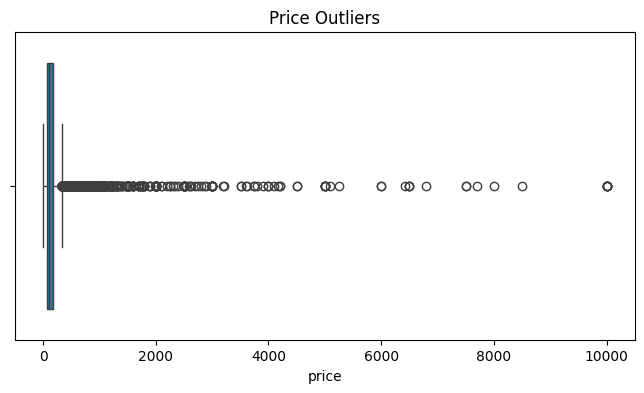

In [11]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['price'])
plt.title("Price Outliers")
plt.show()

In [12]:
df= df[df['price']<1000]

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
,Index: 48576 entries, 0 to 48894
,Data columns (total 16 columns):
, #   Column                          Non-Null Count  Dtype  
,---  ------                          --------------  -----  
, 0   id                              48576 non-null  int64  
, 1   name                            48560 non-null  object 
, 2   host_id                         48576 non-null  int64  
, 3   host_name                       48576 non-null  object 
, 4   neighbourhood_group             48576 non-null  object 
, 5   neighbourhood                   48576 non-null  object 
, 6   latitude                        48576 non-null  float64
, 7   longitude                       48576 non-null  float64
, 8   room_type                       48576 non-null  object 
, 9   price                           48576 non-null  int64  
, 10  minimum_nights                  48576 non-null  int64  
, 11  number_of_reviews               48576 non-null  int64  
, 12  last_review         

In [14]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.857600e+04,4.857600e+04,48576.000000,48576.000000,48576.000000,48576.000000,48576.000000,48576.00000,48576.000000,48576.000000
mean,1.902445e+07,6.763687e+07,40.728920,-73.952027,140.249959,6.976429,23.367157,1.09530,7.170516,112.380188
std,1.097776e+07,7.860465e+07,0.054577,0.046154,112.919452,20.279071,44.644666,1.59979,33.049319,131.376233
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.00000,1.000000,0.000000
25%,9.477863e+06,7.831209e+06,40.690000,-73.982950,69.000000,1.000000,1.000000,0.04000,1.000000,0.000000
50%,1.968164e+07,3.084879e+07,40.722950,-73.955570,105.000000,3.000000,5.000000,0.38000,1.000000,44.000000
75%,2.914961e+07,1.074344e+08,40.763120,-73.936090,175.000000,5.000000,24.000000,1.60000,2.000000,225.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,999.000000,1250.000000,629.000000,58.50000,327.000000,365.000000


In [15]:
df.to_csv("cleaned_airbnb_data.csv",index=False)

In this project, the Airbnb dataset was cleaned by handling missing values, removing duplicates, standardizing formats, and detecting outliers.
These steps improved the quality and reliability of the dataset, making it ready for further analysis or machine learning tasks.